# Linear Regression Review

What is Regression?

Regression is one of the widely used modeling techniques in statistics, econometrics and data science. Its primary purpose is to understand and predict relationships between variables.

At it's core, regression addreses this problem:

- Given a set of input variables (features ), predict a real-valued outcome.

This is known as a regression problem, as opposed to a classification problem where the output is categorical.

Regression analysis is not just about prediction; it is also about explanation and inference. It typically seeks to answer three key questions:

1) Is there a relationship between the predictors and the outcome? In other words, does at least one independent variable help predict the dependent variable?

2) Which variables are the most important predictors? Among many candidate variables, which ones meaningfully explain variation in the outcome?

3) How strong is the influence of each predictor? How much does the outcome change when a predictor changes, holding other variables fixed?


A model is called linear when its predictions are a linear combination of the input variables. This does not require the relationship between variables to look like a straight line in raw space. Instead, linearity refers to being linear in the parameters.

For example, all of the following are linear models:

- $y = \beta_0 + \beta_1x$
- $y = \beta_0 + \beta_1x + \beta_2x^2$
- $y = \beta_0 + \beta_1\log(x)$

They are linear because the coefficients $\beta_j$ enter the model linearly.


Suppose we observe a dataset consisting of $n$ observations:

$$
(x_i, y_i), i=1,...,n
$$

- $x_i$ represents the independent(predictor) variable
- $y_i$ represents the dependent(response) variable

The goal of linear regression is to find a function $f(x)$ that approximates the relationship between $x$ and $y$ as closely as possible.

Linera regression is built on simple but powerful statistical model:

$$
y_i = f(x_i) + \epsilon_i
$$

where:
- $f(x_i)$ is the systematic (deterministic) part of the model
- $\epsilon_i$ is a random error term, representing noise, unobserved factors and measurement error

In simple linear regression, we assume:

$$
f(x_i) = \beta_0 + \beta_1x_i
$$

So, the full model becomes:

$$
y_i = \beta_0 + \beta_1x_i + \epsilon_i
$$

where:

- $\beta_0$ is the intercept: the expected value of $y$ when $x=0$
- $\beta_1$ is the slope: the expected change in $y$ for a one-unit increase in $x$
- $\epsilon_i$ is the error term: random variable capturing all variations in $y$ not explained by x.

Typically, we assume:

- $\mathbb{E}[\epsilon_i] = 0$
- Errors are independent
- Errors have constant variance (homoscedasticity)

Under this framework, $x$ is treated as non-random (or fixed by design) hence it is called the independent or predictor variable. $y$ is random because it depends on the random error term hence it is called the dependent or response variable.


Linear regressino estimates the unknown parameters $\beta_0$ and $\beta_1$ using data. The most common method is Ordinary Least Squares (OLS), which chooses coefficients that minimize the sum of squared residuals.

$$
\min_{\beta_0, \beta_1} \sum_{i=1}^n (y_i - \hat y_i)^2
$$

where:

$$
\hat y_i = \beta_0 + \beta_1x_i
$$

Minimizing the sum of squared errors penalizes large deviations and leads to a unique, closed-form stable solution.

$$
\beta_1 = \frac{\sum (x_i - \bar x)(y_i - \bar y)}{\sum (x_i - \bar x)^2}, \beta_0 = \bar y - \beta_1 \bar x
$$

where:
- $\bar x$ is the sample mean of the predictor
- $\bar y$ is the sample mean of the response

A direct consequence is that the regression line always passes through $(\bar x, \bar y)$.


To measure how well the model explains the data, we use the coefficient of determination:

$$
R^2 = 1 - \frac{\sum(y_i - \hat y_i)^2}{\sum(y_i - \bar y)^2}
$$

It represents the fraction of the total variation in the response explained by the regression model.

Unless the correlation between $x$ and $y$ is perfect, predicted values of $y$ tend to lie closer to the mean of $y$ than extreme values of $x$. This phenomenon is known as regression to the mean and is a fundamental statistical effect, not a causal one.

In [1]:
import seaborn as sns
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error ,r2_score

In [2]:
# load the tips dataset
data = sns.load_dataset('tips')
data.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


We start by modeling the relationship between *total_bill* and the *tip*.

In [3]:
# prepare features and target

X= data[['total_bill']]
y = data['tip']

In [4]:
# initialize and fit the model

model = LinearRegression(fit_intercept=False) # think about why are we not fitting the intercept in this dataset case
model.fit(X, y)

LinearRegression(fit_intercept=False)

In [5]:
# Generate predictions
data['prediction'] = model.predict(X)
print(f"Intercept (beta_0): {model.intercept_}")
print(f"Slope (beta_1): {model.coef_[0]}")

Intercept (beta_0): 0.0
Slope (beta_1): 0.1437318952772166


To understand how well our model performs, we calculate R-squared and the Mean Squared Error

In [6]:
mse = mean_squared_error(y, data['prediction'])
r2 = r2_score(y, data['prediction'])

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 1.1781
R-squared: 0.3821


MSE represents the average squared difference between the observed and the predicted values. R-squared indidcates that approximately 38% of the variance in tips is explained by the total bill.

In [19]:

# Interactive Visualization with Plotly
fig = px.scatter(data, x='total_bill', y='tip', trendline='ols', title='Total Bill vs Tip (with OLS Regression Line)')
fig.show()

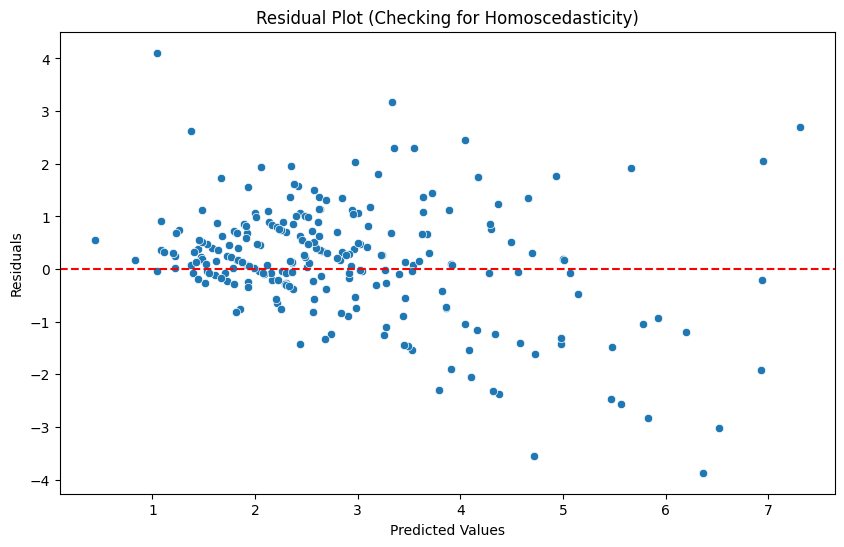

In [20]:
# Residual Analysis
data['residuals'] = data['tip'] - data['prediction']
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['prediction'], y=data['residuals'])
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Checking for Homoscedasticity)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

While OLS has a closed-form solution, most AI models use Gradient Descent to minimize the cost function.

The Cost Function (MSE):

$$
J(\theta) = \frac{1}{n} \sum_{i=1}^n (y_i - \theta x_i)^2
$$

Note: think about why change $\frac{1}{n}$ to $\frac{1}{2n}$ (think about taking the derivative of the cost function)

Also, note that OLS closed-form solution is:

$$
\theta = (X^TX)^{-1} X^Ty
$$

However, calculating the inverse of a matrix has a computational complexity of approximately $O(n^3)$. For modern AI models with millions of features or data points, this is computationally prohibitive. Hence, Gradient Descent avoids matrix inversion by iteratively updating parameters, making it much more scalable.

In [10]:
def mse_given_theta(theta, x, y):
  """
  Calculates MSE for a given slope theta (asusming intercept=0)
  """
  predictions = theta * x
  return np.mean((y-predictions)**2)

In [12]:
# optimization using SciPy
from scipy.optimize import minimize

# start with an initial guess for the slope
result = minimize(lambda t: mse_given_theta(t, data['total_bill'], data['tip']), x0 = 0.1)

print(f"Optimized Slope (Theta): {result.x[0]:.4f}")
print(f"Minimum Cost: {result.fun:.4f}")

Optimized Slope (Theta): 0.1437
Minimum Cost: 1.1781


In a real AI context, we rarely use only one feature. Let's include the size of the party

In [14]:
# Multi-variable features
X_multi = data[['total_bill', 'size']]

In [15]:
multi_model = LinearRegression(fit_intercept=False)
multi_model.fit(X_multi, y)

LinearRegression(fit_intercept=False)

In [17]:
print("Coefficients:")
for col, coef in zip(X_multi.columns, multi_model.coef_):
  print(f"{col}: {coef:.4f}")

Coefficients:
total_bill: 0.1007
size: 0.3621


In [18]:
# compare performance

multi_pred = multi_model.predict(X_multi)
print(f"Multi-variable R^2: {r2_score(y, multi_pred):.4f}")

Multi-variable R^2: 0.4415


From above, we find that there is a clear positive correlation between bill size and tip amount. Our custom optimization (Gradient Descent) yielded results consistent with the closed-form OLS solution. Adding the *party_size* feature improved the model's predictive power, showing that complexity often yields better accuracy, provided we avoid overfitting.